In [1]:
from RL.trainer import SACTrajectoryTrainer

[ SAC ]> Loading configuration from Settings/Test/rl_parameters_test_env.yaml
[ SAC_COST ]> No configuration file provided, using default settings.


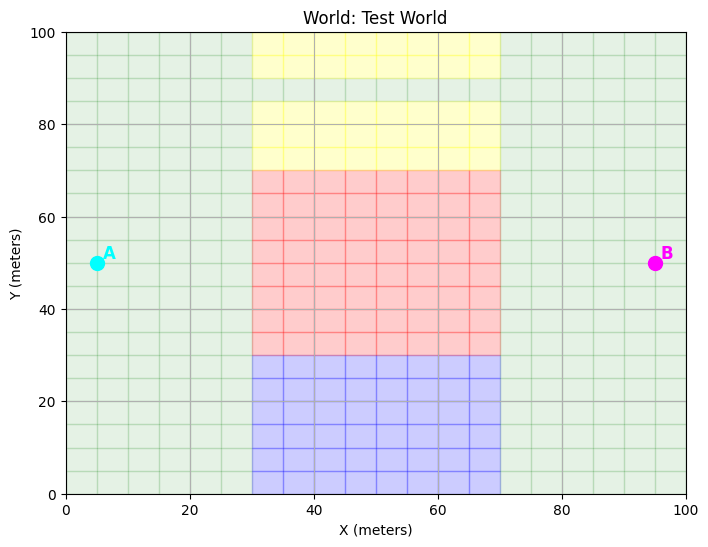

In [2]:
trainer = SACTrajectoryTrainer("Settings/Test/rl_parameters_test_env.yaml",
                               verbose=True,
                               # specific_waypoints=waypoints_manual,
                               run_zero_waypoint_episode=True)
trainer.simulation_object.world.plot_world_from_top(A=trainer.start_point,
                                                    B=trainer.end_point)

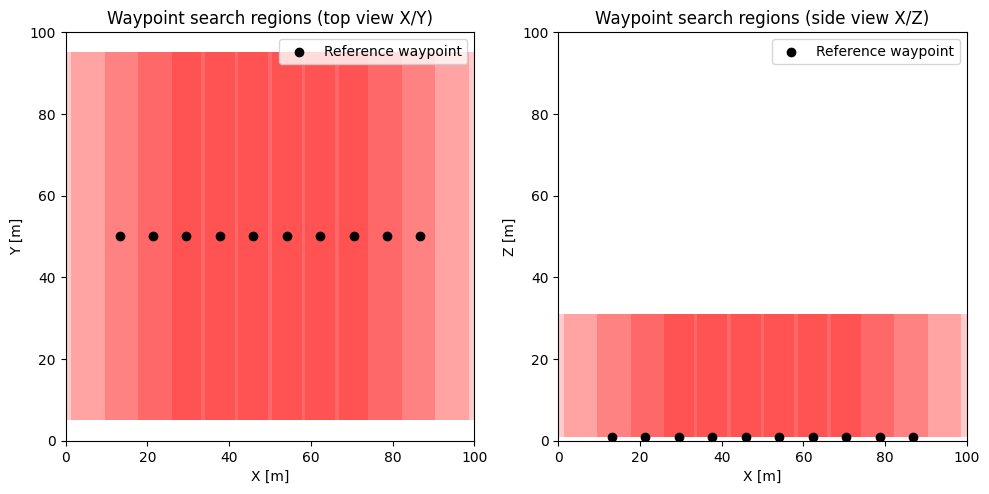

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'Waypoint search regions (top view X/Y)'}, xlabel='X [m]', ylabel='Y [m]'>,
        <Axes: title={'center': 'Waypoint search regions (side view X/Z)'}, xlabel='X [m]', ylabel='Z [m]'>],
       dtype=object))

In [3]:
trainer.environment.plot_waypoint_search_regions(alpha=0.20, figsize=(10, 6))

In [4]:
trainer.start_optimization()

[ SAC_COST ]> No configuration file provided, using default settings.
[ SAC_COST ]> No configuration file provided, using default settings.


TypeError: startSimulation() got an unexpected keyword argument 'stop_when_reaching_point'

In [ ]:
best_params = trainer.best_params
print("Best parameters found by RL agent:", best_params)

Best parameters found by RL agent: [{'x': 27.664927049116653, 'y': 88.29509735107422, 'z': 10.923457145690918, 'v': 18.322269439697266}, {'x': 37.11072626980868, 'y': 85.373291015625, 'z': 23.00494384765625, 'v': 13.508941650390625}, {'x': 74.18110830133611, 'y': 89.29581451416016, 'z': 26.83894920349121, 'v': 15.422500610351562}, {'x': 95.0, 'y': 50.0, 'z': 1.0, 'v': 15.422500610351562}]


In [ ]:
best_params = [{"x": 24.17581575567072, "y": 68.24645233154297, "z": 7.310683250427246, "v": 12.179763793945312}, {"x": 34.75761465592818, "y": 90.09334564208984, "z": 13.302192687988281, "v": 19.205364227294922}, {"x": 51.345872185447, "y": 89.00727844238281, "z": 29.660045623779297, "v": 11.398324012756348}, {"x": 81.97016872059216, "y": 87.92033386230469, "z": 26.42989158630371, "v": 18.743364334106445}, {"x": 78.77400190179998, "y": 22.900564193725586, "z": 25.39923095703125, "v": 11.893746376037598}, {"x": 95.0, "y": 50.0, "z": 1.0, "v": 11.893746376037598}]

[  ]> No configuration file provided, using default settings.
Final target reached at time: 22.35 s
Simulation completed in 4.96 seconds.
Costs: {'total_cost': 64.18007037989081, 'time_cost': 22.352, 'power_cost': 12.543752392578126, 'noise_cost': 23.214283816473202, 'completion_cost': 0.0, 'n_waypoints_completed': 6, 'tot_waypoints': 6}


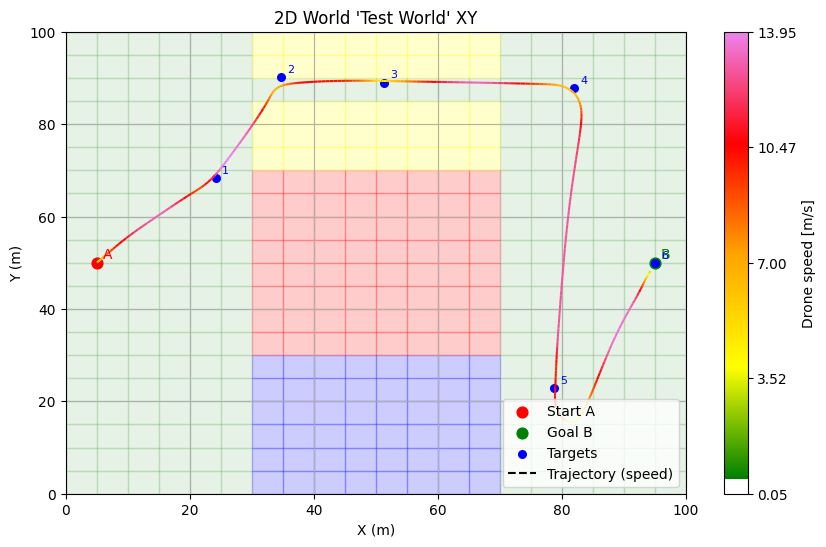

In [ ]:
# Import best trajectory found by RL agent into main simulation for visualization and analysis
from main import *
from Optimizations.optimizer import Optimizer as CostWrapper
from Utils.plotting_functions import show2DWorld, show3DWorld


parameters = trainer.simulation_parameters
init_state = create_initial_state(*trainer.start_point)
waypoints_selected = best_params

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

A = parameters['start_point']
B = parameters['end_point']

sim = Simulation(
    drone,
    world,
    waypoints_selected,
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

cw = CostWrapper(sim, "")

cw.simulation_object.startSimulation(stop_at_target=True, use_static_target=False, verbose=True)
print(f"Costs: {cw.calculate_costs()}")
max_world_size = cw.simulation_object.world.max_world_size
show2DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, horiz_speed_history=cw.simulation_object.horiz_speed_history, vertical_speed_history=cw.simulation_object.vertical_speed_history)

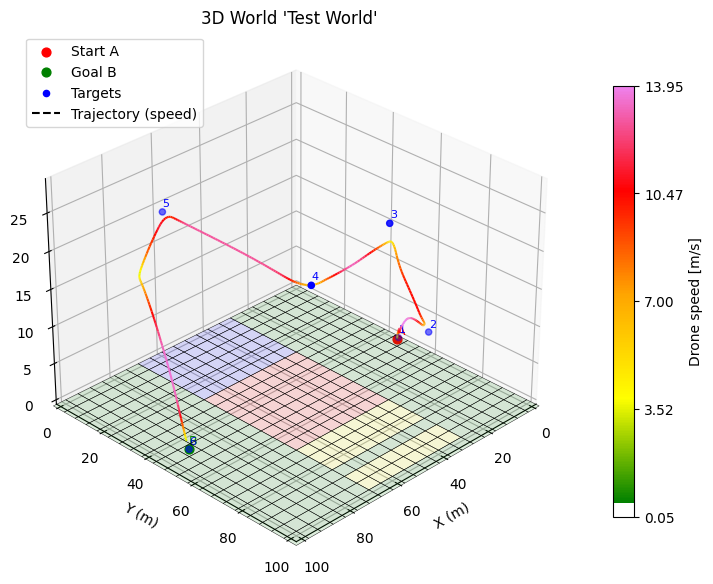

In [ ]:
show3DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, 
    horiz_speed_history=cw.simulation_object.horiz_speed_history, 
    vertical_speed_history=cw.simulation_object.vertical_speed_history,
    view_pov=(30, 45))

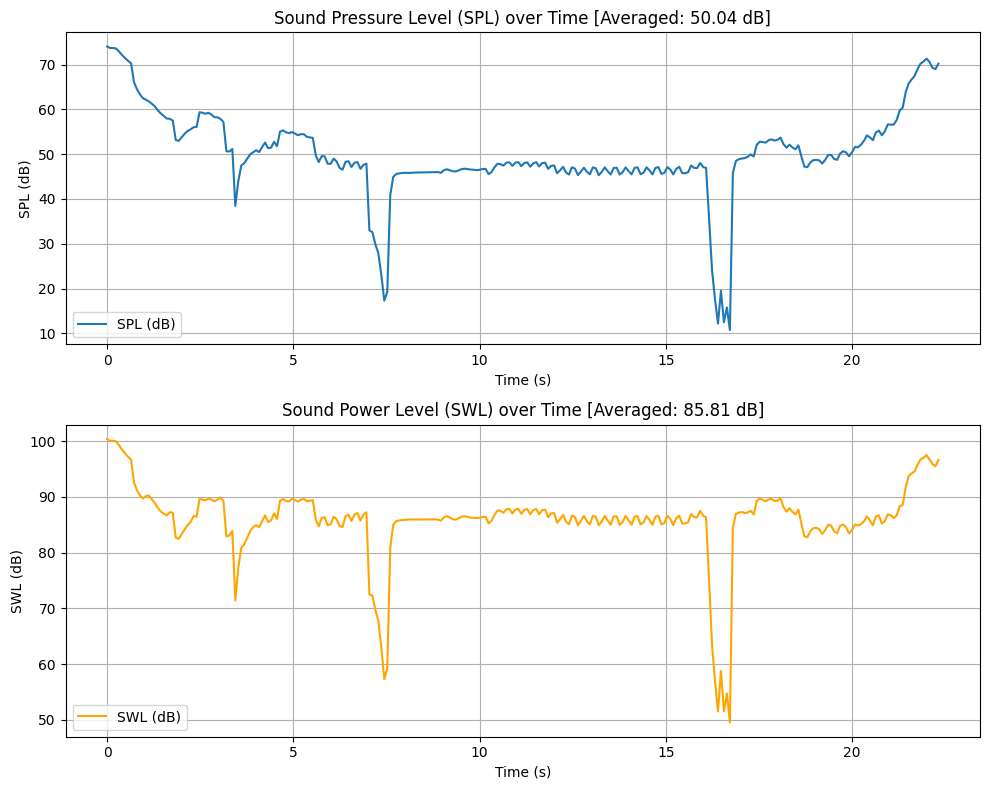

In [ ]:
# Plot SPL history and SWL history in subplots
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(cw.simulation_object.time_history, cw.simulation_object.spl_history, label='SPL (dB)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('SPL (dB)')
ax1.set_title(f'Sound Pressure Level (SPL) over Time [Averaged: {np.mean(cw.simulation_object.spl_history):.2f} dB]')
ax1.grid()
ax1.legend()
ax2.plot(cw.simulation_object.time_history, cw.simulation_object.swl_history, label='SWL (dB)', color='orange')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('SWL (dB)')
ax2.set_title(f'Sound Power Level (SWL) over Time [Averaged: {np.mean(cw.simulation_object.swl_history):.2f} dB]')
ax2.grid()
ax2.legend()
plt.tight_layout()
plt.show()